In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

create agent state schema

In [2]:
class AgentState(TypedDict):
    name: str
    age: int
    final: str

create node

In [3]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence"""
    
    state['final'] = f"hello {state["name"]}"
    
    return state


def second_node(state: AgentState) -> AgentState:
    """This is the second node of our sequence"""
    
    state['final'] += f" and you are {state["age"]} years old"
    
    return state

create the graph structure

In [4]:
graph = StateGraph(AgentState)
graph.add_node("this_is_first_node", first_node)   # name, action/function
graph.add_node("this_is_second_node", second_node)   # name, action/function
graph.set_entry_point("this_is_first_node")
graph.add_edge("this_is_first_node", "this_is_second_node")  # from, to
graph.set_finish_point("this_is_second_node")

app = graph.compile()

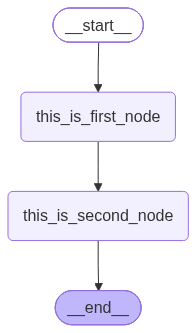

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))  # display the graph as an image in the notebook

invoke graph

In [6]:
input = AgentState(name="Matty", age=25)
ans = app.invoke(input)  # invoke the graph with the initial state

In [7]:
ans

{'name': 'Matty', 'age': 25, 'final': 'hello Matty and you are 25 years old'}

In [9]:
ans['final']  # print the final state after the graph execution

'hello Matty and you are 25 years old'